C:\Users\ELCOT\AppData\Local\Temp\ipykernel_16064\4207025373.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


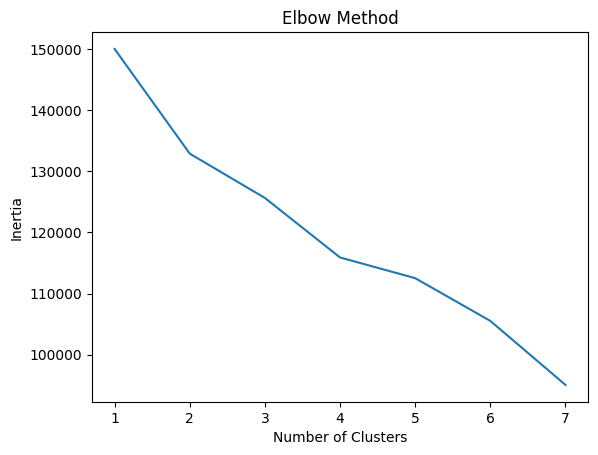

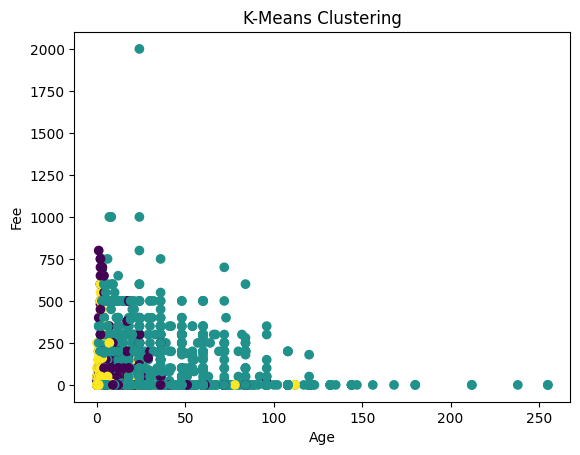

['kmeans_model.joblib']

In [3]:
# =========================
# PROGRAM 3: K-MEANS
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("petfinder-mini.csv")

df = df.drop(columns=['Name','PetID','Description'], errors='ignore')
df.fillna(0, inplace=True)

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('AdoptionSpeed', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertia = []
for k in range(1,8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,8), inertia)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Final Model
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

# Visualization (Age vs Fee)
plt.figure()
plt.scatter(df['Age'], df['Fee'], c=df['Cluster'])
plt.xlabel("Age")
plt.ylabel("Fee")
plt.title("K-Means Clustering")
plt.show()

# Save KMeans model
joblib.dump(kmeans, "kmeans_model.joblib")